# TREND FOLLOWING USING TECH INDICATORS- LONG ONLY STRAT

### __Executive Summary – Trend-Following Overlay Strategy__

This notebook implements a systematic trend-following long-only overlay applied to a diversified multi-asset portfolio (equities and crypto).
The strategy is designed as a low-volatility, capital-efficient sleeve to complement long-term core holdings.

__Definition of Trend__

In this framework, a trend is defined as persistent positive momentum in a smoothed signal.
1. __Score Smoothing__

$$
Score^{smooth}_t = \text{Smooth}(Score_t)
$$

Where Smooth() can be:
Exponential Moving Average (EMA)
Double EMA (DEMA)
Rolling mean
Rolling median

2. __Momentum Definition__

Trend momentum is defined as:

$$
mom_t = Score^{smooth}_t - Score^{smooth}_{t-L}
$$


3. __Trend Condition (Long/Flat)__

   
A positive trend exists when:

$$
Signal_t =
\begin{cases}
1 & \text{if } mom_t > band \\
0 & \text{otherwise}
\end{cases}
$$

This implies that the smoothed score has increased meaningfully over the lookback window.
If this condition is not satisfied, the asset is considered non-trending and the position is set to flat.
There is no separate exit rule:
trend deterioration automatically switches the signal off.


5. __Core Logic__

   
The strategy combines:

Trend Filter (Long/Flat) -> Exposure is active only when trend momentum is positive.

Each asset has structural weights, computed as inverse vol. weights.

To make the exposure more dynamic, in an attempt to reduce drawdowns we apply vol. targets to each asset:

Volatility Targeting (No Leverage)
$$
Scale_t = \min \left( \frac{TargetVol}{\sigma_t}, 1.0 \right)
$$

Exposure is scaled according to realized volatility:

$$
Exposure_{i,t} = Signal_{i,t} \cdot Scale_{i,t} \cdot w_i
$$


#### Importing packages:

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import product
import os
import warnings
warnings.filterwarnings("ignore")

# AUXILIARY FUNCTIONS (Core ones):

In [26]:
# ---------- ordering helper (Series or DataFrame) ----------

def ensure_time_sorted(x):
    """Ensure index is increasing from oldest to newest."""
    if not x.index.is_monotonic_increasing:
        return x.sort_index()
    return x

# ---------- smoothing ----------

def smooth_score(
    score: pd.Series,
    method: str = "ema",
    span: int = 40,
    window: int = 21,
    min_periods: int | None = None
) -> pd.Series:
    score = ensure_time_sorted(score.astype(float))

    if min_periods is None:
        min_periods = max(3, int(span / 3)) if method in ("ema", "dema") else max(3, int(window / 3))

    if method == "ema":
        return score.ewm(span=span, adjust=False, min_periods=min_periods).mean()

    if method == "dema":
        ema1 = score.ewm(span=span, adjust=False, min_periods=min_periods).mean()
        return ema1.ewm(span=span, adjust=False, min_periods=min_periods).mean()

    if method == "median":
        return score.rolling(window=window, min_periods=min_periods).median()

    if method == "mean":
        return score.rolling(window=window, min_periods=min_periods).mean()

    raise ValueError("method must be one of: 'ema', 'dema', 'median', 'mean'")

# ---------- signal (with side) ----------

def trend_follow_signal_single(
    score_s: pd.Series,
    mom_lb: int = 20,
    band: float = 0.0,
    side: str = "both",      # "long", "short", "both"
    fill_method: str = "ffill"
) -> pd.Series:
    if side not in ("long", "short", "both"):
        raise ValueError("side must be one of: 'long', 'short', 'both'")

    score_s = ensure_time_sorted(score_s.astype(float))
    mom = score_s.diff(mom_lb)

    if side == "both":
        pos = np.where(mom > band, 1.0, np.where(mom < -band, -1.0, 0.0))
    elif side == "long":
        pos = np.where(mom > band, 1.0, 0.0)
    else:  # "short"
        pos = np.where(mom < -band, -1.0, 0.0)

    pos = pd.Series(pos, index=score_s.index)

    if fill_method == "ffill":
        pos = pos.ffill().fillna(0.0)

    return pos

# ---------- trades (single source of truth) ----------

def compute_trade_returns_compounded(pos: pd.Series, strat_ret: pd.Series) -> pd.Series:
    """
    Trade = constant non-zero position segment.
    Trade return = compound product (1+r) - 1 over that segment.
    """
    pos = pos.fillna(0.0)
    strat_ret = strat_ret.fillna(0.0)

    change = pos.ne(pos.shift(1)).fillna(False)
    seg_id = change.cumsum()

    seg = pd.DataFrame({"pos": pos, "ret": strat_ret, "seg": seg_id})
    seg = seg[seg["pos"] != 0.0]
    if seg.empty:
        return pd.Series(dtype=float, name="trade_return")

    trade_ret = seg.groupby("seg")["ret"].apply(lambda x: (1 + x).prod() - 1)
    trade_ret.name = "trade_return"
    return trade_ret

def trade_stats_from_trade_returns(trade_ret: pd.Series) -> dict:
    if trade_ret is None or len(trade_ret) == 0:
        return {"n_trades": 0, "n_winning_trades": 0, "hit_ratio": np.nan, "avg_trade_return": np.nan}
    n_trades = int(trade_ret.shape[0])
    n_win = int((trade_ret > 0).sum())
    hit = n_win / n_trades if n_trades else np.nan
    return {
        "n_trades": n_trades,
        "n_winning_trades": n_win,
        "hit_ratio": hit,
        "avg_trade_return": float(trade_ret.mean()),
    }

# ---------- perf metrics ----------

def perf_metrics(strat_ret: pd.Series, periods_per_year: int = 252) -> dict:
    strat_ret = strat_ret.dropna()
    if len(strat_ret) == 0:
        return {"sharpe": np.nan, "sortino": np.nan, "total_pnl": np.nan, "total_vol": np.nan}

    total_pnl = (1.0 + strat_ret).prod() - 1.0
    ann_vol = strat_ret.std(ddof=0) * np.sqrt(periods_per_year)
    ann_ret = strat_ret.mean() * periods_per_year
    sharpe = np.nan if ann_vol == 0 else ann_ret / ann_vol

    downside = strat_ret[strat_ret < 0]
    downside_std = downside.std(ddof=0) * np.sqrt(periods_per_year)
    sortino = np.nan if downside_std == 0 else ann_ret / downside_std

    return {"sharpe": sharpe, "sortino": sortino, "total_pnl": total_pnl, "total_vol": ann_vol}

def rolling_sharpe(ret: pd.Series, window: int = 252, periods_per_year: int = 252) -> pd.Series:
    ret = ret.astype(float)
    mu = ret.rolling(window).mean() * periods_per_year
    vol = ret.rolling(window).std(ddof=0) * np.sqrt(periods_per_year)
    rs = mu / vol
    rs.name = f"rolling_sharpe_{window}"
    return rs


def annual_returns(strat_ret: pd.Series) -> pd.Series:
    r = strat_ret.dropna()
    return (1 + r).groupby(r.index.year).prod() - 1


def rolling_sharpe_by_year(rolling_sharpe: pd.Series) -> pd.Series:
    rs = rolling_sharpe.dropna()
    return rs.groupby(rs.index.year).mean()


# ---------- main backtester (single asset) ----------

def backtest_trend_following_single(
    df_asset: pd.DataFrame,
    price_col: str = "Close",
    score_col: str = "Score",
    smooth_method: str = "ema",
    smooth_span: int = 40,
    smooth_window: int = 21,
    mom_lb: int = 20,
    band: float = 0.0,
    side: str = "both",      # <--- NEW
    cost_bps: float = 0.0,
    periods_per_year: int = 252
):
    df_asset = ensure_time_sorted(df_asset.copy()).dropna(subset=[price_col, score_col])

    price = df_asset[price_col].astype(float)
    score = df_asset[score_col].astype(float)

    ret = price.pct_change()

    score_s = smooth_score(score, method=smooth_method, span=smooth_span, window=smooth_window)
    pos = trend_follow_signal_single(score_s, mom_lb=mom_lb, band=band, side=side).reindex(df_asset.index).fillna(0.0)

    strat_ret_gross = pos.shift(1) * ret

    turnover = pos.diff().abs().fillna(0.0)
    cost = turnover * (cost_bps * 1e-4)

    strat_ret_net = (strat_ret_gross - cost).fillna(0.0)

    trade_ret = compute_trade_returns_compounded(pos, strat_ret_net)
    trade_stats = trade_stats_from_trade_returns(trade_ret)
    metrics = perf_metrics(strat_ret_net, periods_per_year=periods_per_year)

    summary = {**trade_stats, **metrics}

    details = pd.DataFrame({
        "Close": price,
        "Score": score,
        "Score_S": score_s,
        "Pos": pos,
        "Ret": ret,
        "StratRet_gross": strat_ret_gross,
        "Cost": cost,
        "StratRet_net": strat_ret_net
    })

    return pd.Series(summary).sort_index(), details, trade_ret

# ---------- plots (simple) ----------

def plot_strategy_summary_report(
    strat_ret: pd.Series,
    pos: pd.Series,
    title: str = "Strategy Summary",
    sharpe_window: int = 252,
    periods_per_year: int = 252,
    trade_bins: int = 60
):
    # ---------- align ----------
    idx = strat_ret.index.union(pos.index)
    r = strat_ret.reindex(idx).astype(float).fillna(0.0)
    p = pos.reindex(idx).astype(float).fillna(0.0)

    # ---------- equity ----------
    equity = (1 + r).cumprod()

    plt.figure(figsize=(10, 4))
    equity.plot()
    plt.title(f"{title} — Equity Curve")
    plt.ylabel("Growth of 1")
    plt.xlabel("Date")
    plt.show()

    # ---------- drawdown ----------
    dd = equity / equity.cummax() - 1.0

    plt.figure(figsize=(10, 3))
    dd.plot()
    plt.title(f"{title} — Drawdown")
    plt.ylabel("Drawdown")
    plt.xlabel("Date")
    plt.show()

    # ---------- rolling sharpe ----------
    rs = rolling_sharpe(r, window=sharpe_window, periods_per_year=periods_per_year)

    plt.figure(figsize=(10, 3))
    rs.plot()
    plt.axhline(0.0, linewidth=1)
    plt.title(f"{title} — Rolling Sharpe ({sharpe_window} obs)")
    plt.ylabel("Sharpe")
    plt.xlabel("Date")
    plt.show()

    # ---------- rolling sharpe by year ----------
    rs_year = rolling_sharpe_by_year(rs)

    plt.figure(figsize=(8, 4))
    rs_year.plot(kind="bar")
    plt.axhline(0.0, linewidth=1)
    plt.title(f"{title} — Avg Rolling Sharpe by Year")
    plt.ylabel("Sharpe")
    plt.xlabel("Year")
    plt.show()

    # ---------- annual returns ----------
    ann_ret = annual_returns(r)

    plt.figure(figsize=(8, 4))
    ann_ret.plot(kind="bar")
    plt.axhline(0.0, linewidth=1)
    plt.title(f"{title} — Annual Returns")
    plt.ylabel("Return")
    plt.xlabel("Year")
    plt.show()

    # ---------- trade distribution ----------
    trade_ret = compute_trade_returns_compounded(p, r)

    plt.figure(figsize=(8, 4))
    if len(trade_ret) == 0:
        plt.text(0.5, 0.5, "No trades", ha="center", va="center")
        plt.axis("off")
    else:
        trade_ret.hist(bins=trade_bins)
        plt.title(f"{title} — Trade Return Distribution")
        plt.xlabel("Trade return (compounded)")
        plt.ylabel("Count")
    plt.show()

    return {
        "annual_returns": ann_ret,
        "rolling_sharpe": rs,
        "rolling_sharpe_by_year": rs_year,
        "trade_returns": trade_ret
    }

def grid_search_tf(
    df_asset: pd.DataFrame,
    price_col: str = "Close",
    score_col: str = "Score",
    smooth_methods=("ema", "dema"),
    smooth_spans=(20, 30, 40, 60),
    smooth_windows=(11, 21, 31),   # usato solo per mean/median
    mom_lbs=(10, 20, 40),
    bands=(0.0, 0.2, 0.4),
    sides=("long", "both"),        # puoi mettere anche "short"
    cost_bps: float = 0.0,
    periods_per_year: int = 252,
    sort_by: str = "sharpe",
    ascending: bool = False,
    max_rows: int | None = None
) -> pd.DataFrame:
    rows = []

    for method, span, window, mom_lb, band, side in product(
        smooth_methods, smooth_spans, smooth_windows, mom_lbs, bands, sides
    ):
        # opzionale: evita combinazioni inutili per velocità
        if method in ("ema", "dema"):
            # window non rilevante: teniamo solo il primo
            if window != smooth_windows[0]:
                continue
        if method in ("mean", "median"):
            # span non rilevante: tieni solo il primo
            if span != smooth_spans[0]:
                continue

        rows.append(
            backtest_tf_summary(
                df_asset=df_asset,
                price_col=price_col,
                score_col=score_col,
                smooth_method=method,
                smooth_span=span,
                smooth_window=window,
                mom_lb=mom_lb,
                band=band,
                side=side,
                cost_bps=cost_bps,
                periods_per_year=periods_per_year
            )
        )

    out = pd.DataFrame(rows).sort_values(sort_by, ascending=ascending).reset_index(drop=True)
    if max_rows is not None:
        out = out.head(max_rows)
    return out
    
def backtest_tf_summary(
    df_asset: pd.DataFrame,
    price_col: str = "Close",
    score_col: str = "Score",
    smooth_method: str = "ema",
    smooth_span: int = 40,
    smooth_window: int = 21,
    mom_lb: int = 20,
    band: float = 0.0,
    side: str = "both",
    cost_bps: float = 0.0,
    periods_per_year: int = 252
) -> dict:
    df_asset = ensure_time_sorted(df_asset.copy()).dropna(subset=[price_col, score_col])

    price = df_asset[price_col].astype(float)
    score = df_asset[score_col].astype(float)
    ret = price.pct_change()

    score_s = smooth_score(score, method=smooth_method, span=smooth_span, window=smooth_window)
    pos = trend_follow_signal_single(score_s, mom_lb=mom_lb, band=band, side=side).reindex(df_asset.index).fillna(0.0)

    strat_ret_gross = pos.shift(1) * ret
    turnover = pos.diff().abs().fillna(0.0)
    cost = turnover * (cost_bps * 1e-4)
    strat_ret_net = (strat_ret_gross - cost).fillna(0.0)

    trade_ret = compute_trade_returns_compounded(pos, strat_ret_net)
    tstats = trade_stats_from_trade_returns(trade_ret)
    pstats = perf_metrics(strat_ret_net, periods_per_year=periods_per_year)

    return {
        "smooth_method": smooth_method,
        "smooth_span": int(smooth_span),
        "smooth_window": int(smooth_window),
        "mom_lb": int(mom_lb),
        "band": float(band),
        "side": side,
        "cost_bps": float(cost_bps),
        **tstats,
        **pstats
    }

def split_train_test(df_asset: pd.DataFrame, split_date: str | None = None, train_frac: float = 0.7):
    df_asset = ensure_time_sorted(df_asset.copy())
    if split_date is not None:
        split_date = pd.to_datetime(split_date)
        train = df_asset.loc[df_asset.index < split_date]
        test  = df_asset.loc[df_asset.index >= split_date]
    else:
        cut = int(len(df_asset) * train_frac)
        train = df_asset.iloc[:cut]
        test  = df_asset.iloc[cut:]
    return train, test

def grid_search_tf_train_test(
    df_asset: pd.DataFrame,
    split_date: str | None = "2022-01-01",   # cambia se vuoi
    train_frac: float = 0.7,
    **grid_kwargs
) -> pd.DataFrame:
    train, test = split_train_test(df_asset, split_date=split_date, train_frac=train_frac)

    grid_train = grid_search_tf(train, **grid_kwargs)
    # per ogni riga train, ricalcola su test
    rows = []
    for _, row in grid_train.iterrows():
        params = {
            "smooth_method": row["smooth_method"],
            "smooth_span": int(row["smooth_span"]),
            "smooth_window": int(row["smooth_window"]),
            "mom_lb": int(row["mom_lb"]),
            "band": float(row["band"]),
            "side": row["side"],
            "cost_bps": float(row["cost_bps"]),
        }
        test_res = backtest_tf_summary(test, **params)
        rows.append({
            **{f"train_{k}": row[k] for k in ["sharpe","sortino","total_pnl","total_vol","n_trades","hit_ratio"]},
            **{f"test_{k}": test_res[k] for k in ["sharpe","sortino","total_pnl","total_vol","n_trades","hit_ratio"]},
            **params
        })

    out = pd.DataFrame(rows)
    out["robust_score"] = out["test_sharpe"] - 0.5 * (out["train_sharpe"] - out["test_sharpe"]).abs()
    out = out.sort_values("robust_score", ascending=False).reset_index(drop=True)
    return out


def apply_vol_targeting_no_leverage(
    strat_ret: pd.Series,
    target_vol: float = 0.08,      # 8% annuo 
    vol_window: int = 60,          # 60 giorni
    periods_per_year: int = 252
) -> pd.DataFrame:
    """
    Returns a DataFrame with:
      - scaling (0..1)
      - realized_vol (annualized)
      - strat_ret_vt (vol-targeted returns, no leverage)
    """
    r = strat_ret.astype(float).fillna(0.0)

    realized_vol = r.rolling(vol_window).std(ddof=0) * np.sqrt(periods_per_year)
    scaling = (target_vol / realized_vol).clip(lower=0.0, upper=1.0).shift(1)  # no look-ahead

    r_vt = (scaling * r).fillna(0.0)

    out = pd.DataFrame({
        "scaling": scaling,
        "realized_vol": realized_vol,
        "strat_ret_vt": r_vt
    })
    return out

#---- realized vol function----#

def realized_vol_from_price(
    price: pd.Series,
    window: int = 120,
    periods_per_year: int = 252
) -> pd.Series:
    price = price.astype(float)
    ret = price.pct_change()

    vol = (
        ret.rolling(window)
           .std(ddof=0)
           * np.sqrt(periods_per_year)
    )
    return vol
    
#######################
def get_asset_df(df_panel: pd.DataFrame, asset: str) -> pd.DataFrame:
    out = df_panel.loc[:, (asset, ["Close", "Score"])].copy()
    out.columns = ["Close", "Score"]
    if not out.index.is_monotonic_increasing:
        out = out.sort_index()
    return out

def vol_scaling_from_price(
    price: pd.Series,
    target_vol: float,
    window: int,
    periods_per_year: int = 252,
    max_scale: float = 1.0
) -> pd.Series:
    price = price.astype(float)
    if not price.index.is_monotonic_increasing:
        price = price.sort_index()

    ret = price.pct_change()
    rv = ret.rolling(window).std(ddof=0) * np.sqrt(periods_per_year)
    scale = (target_vol / rv).clip(lower=0.0, upper=max_scale).shift(1)  # no look-ahead
    return scale

def tf_pos_from_score(
    score: pd.Series,
    smooth_method: str,
    smooth_span: int,
    smooth_window: int,
    mom_lb: int,
    band: float,
    side: str = "long"
) -> pd.Series:
    # score smoothing
    score_s = smooth_score(score, method=smooth_method, span=smooth_span, window=smooth_window)

    # momentum on smoothed score
    mom = score_s.diff(mom_lb)

    if side == "long":
        pos = (mom > band).astype(float)  # 1 when signal ON else 0
    elif side == "short":
        pos = -(mom < -band).astype(float)  # -1/0
    elif side == "both":
        pos = np.where(mom > band, 1.0, np.where(mom < -band, -1.0, 0.0))
        pos = pd.Series(pos, index=score.index).astype(float)
    else:
        raise ValueError("side must be 'long', 'short', or 'both'")

    pos = pos.reindex(score.index).fillna(0.0)
    return pos

# ---------- main portfolio simulator ----------
def simulate_portfolio(
    df_panel: pd.DataFrame,
    assets: list[str],
    best_params: dict,
    weights: pd.Series,
    target_vol_by_asset: dict,
    vol_window_by_asset: dict,
    initial_capital: float = 100.0,
    periods_per_year: int = 252,
    max_scale: float = 1.0,
):
    # containers
    close_df, ret_df, pos_df, scale_df = {}, {}, {}, {}

    for a in assets:
        df_a = get_asset_df(df_panel, a).dropna()
        close = df_a["Close"]
        score = df_a["Score"]

        # returns
        ret = close.pct_change()

        # signal/pos
        p = best_params[a]
        pos = tf_pos_from_score(
            score=score,
            smooth_method=p["smooth_method"],
            smooth_span=p["smooth_span"],
            smooth_window=p.get("smooth_window", 21),
            mom_lb=p["mom_lb"],
            band=p["band"],
            side=p.get("side", "long")
        )

        # vol scaling
        scale = vol_scaling_from_price(
            price=close,
            target_vol=target_vol_by_asset[a],
            window=vol_window_by_asset[a],
            periods_per_year=periods_per_year,
            max_scale=max_scale
        )

        close_df[a] = close
        ret_df[a] = ret
        pos_df[a] = pos
        scale_df[a] = scale

    # align on common index
    common_idx = None
    for a in assets:
        idx = close_df[a].index
        common_idx = idx if common_idx is None else common_idx.intersection(idx)

    Close = pd.DataFrame({a: close_df[a].reindex(common_idx) for a in assets})
    Ret   = pd.DataFrame({a: ret_df[a].reindex(common_idx).fillna(0.0) for a in assets})
    Pos   = pd.DataFrame({a: pos_df[a].reindex(common_idx).fillna(0.0) for a in assets})
    Scale = pd.DataFrame({a: scale_df[a].reindex(common_idx).fillna(0.0) for a in assets})

    # weights (Series) aligned
    w = weights.reindex(assets).astype(float)
    w = w / w.sum()

    # exposures (time-varying) BEFORE execution shift
    Exposure = Pos.mul(Scale).mul(w, axis=1)

    # apply exposures with shift(1) to avoid look-ahead (trade end of day t -> earn return t+1)
    Exposure_exec = Exposure.shift(1).fillna(0.0)

    # portfolio return = sum_i exposure_i * asset_return_i
    port_ret = (Exposure_exec * Ret).sum(axis=1)
    port_ret.name = "PortfolioRet"

    equity = initial_capital * (1.0 + port_ret).cumprod()
    equity.name = "Equity"

    # drawdown
    dd = equity / equity.cummax() - 1.0
    dd.name = "Drawdown"

    # summary stats
    ann_ret = port_ret.mean() * periods_per_year
    ann_vol = port_ret.std(ddof=0) * np.sqrt(periods_per_year)
    sharpe = np.nan if ann_vol == 0 else ann_ret / ann_vol
    total_pnl = equity.iloc[-1] / initial_capital - 1.0
    max_dd = dd.min()

    summary = pd.Series({
        "initial_capital": initial_capital,
        "final_equity": float(equity.iloc[-1]),
        "total_return": float(total_pnl),
        "ann_return": float(ann_ret),
        "ann_vol": float(ann_vol),
        "sharpe": float(sharpe),
        "max_drawdown": float(max_dd),
    })

    # a clean run-sheet dataframe
    run = pd.concat([
        Close.add_prefix("Close_"),
        Pos.add_prefix("Pos_"),
        Scale.add_prefix("Scale_"),
        Exposure.add_prefix("WgtExp_"),
        Exposure_exec.add_prefix("ExecExp_"),
        Ret.add_prefix("Ret_"),
        port_ret,
        equity,
        dd
    ], axis=1)

    return summary, run, Exposure, Exposure_exec

# ---- rolling sharpe helper ----
def rolling_sharpe(ret: pd.Series, window: int = 252, periods_per_year: int = 252) -> pd.Series:
    ret = ret.astype(float)
    mu = ret.rolling(window).mean() * periods_per_year
    vol = ret.rolling(window).std(ddof=0) * np.sqrt(periods_per_year)
    rs = mu / vol
    rs.name = f"rolling_sharpe_{window}"
    return rs

# ---- portfolio plots ----
def plot_portfolio_report(run: pd.DataFrame, title: str = "Portfolio", sharpe_window: int = 252, periods_per_year: int = 252):
    """
    Expects columns in `run`: 'Equity', 'Drawdown', 'PortfolioRet'
    (as created by simulate_portfolio()).
    """
    equity = run["Equity"].astype(float)
    dd = run["Drawdown"].astype(float)
    r = run["PortfolioRet"].astype(float).fillna(0.0)

    # Equity
    plt.figure()
    equity.plot()
    plt.title(f"{title} — Equity Curve (Capital Growth)")
    plt.xlabel("Date")
    plt.ylabel("Equity")
    plt.show()

    # Drawdown
    plt.figure()
    dd.plot()
    plt.title(f"{title} — Drawdown")
    plt.xlabel("Date")
    plt.ylabel("Drawdown")
    plt.show()

    # Rolling Sharpe
    rs = rolling_sharpe(r, window=sharpe_window, periods_per_year=periods_per_year)
    plt.figure()
    rs.plot()
    plt.axhline(0.0, linewidth=1)
    plt.title(f"{title} — Rolling Sharpe ({sharpe_window} obs)")
    plt.xlabel("Date")
    plt.ylabel("Sharpe")
    plt.show()

    # Annual returns (bar chart)
    ann = (1 + r).groupby(r.index.year).prod() - 1
    plt.figure()
    ann.plot(kind="bar")
    plt.title(f"{title} — Annual Returns")
    plt.xlabel("Year")
    plt.ylabel("Return")
    plt.show()

    return rs, ann


def build_daily_monitoring_v2(
    pos_df: pd.DataFrame,
    pos_exec: pd.DataFrame,
    flip_df: pd.DataFrame,
    scaling_df: pd.DataFrame,
    exposure_df: pd.DataFrame,
    ret_df: pd.DataFrame,
    w: pd.Series,
):
    # --- robust datetime index ---
    for df in [pos_df, pos_exec, flip_df, scaling_df, exposure_df, ret_df]:
        if not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.to_datetime(df.index)
        df.sort_index(inplace=True)

    today = pos_df.index[-1]
    same_month = (pos_df.index.to_period("M") == today.to_period("M"))
    month_start = pos_df.index[same_month][0]

    assets = list(w.index)
    rows = []

    for a in assets:
        sig_daily = float(pos_df.loc[today, a])
        sig_exec  = float(pos_exec.loc[today, a])
        flip      = int(flip_df.loc[today, a])

        scale_today = float(scaling_df.loc[today, a])
        base_w      = float(w.loc[a])
        exp_today   = float(exposure_df.loc[today, a])

        # MTD contribution (consistent with execution shift)
        exp_exec = exposure_df[a].shift(1).fillna(0.0)
        pnl_mtd = float((exp_exec.loc[month_start:today] * ret_df.loc[month_start:today, a]).sum())

        rows.append({
            "Asset": a,
            "Signal_daily": sig_daily,
            "Signal_exec": sig_exec,
            "Flip": flip,
            "Base_weight": base_w,
            "Scale_today": scale_today,
            "Exposure_today": exp_today,
            "MTD_PnL": pnl_mtd,
        })

    mon = pd.DataFrame(rows).set_index("Asset")

    # ordering: what needs attention first
    mon = mon.sort_values(["Flip", "MTD_PnL"], ascending=[False, True])
    return mon

    
def build_trade_sheet_with_units(
    exposure_df: pd.DataFrame,
    close_df: pd.DataFrame,
    nav_live: float,
    min_trade_eur: float = 0.0
):
    if not isinstance(exposure_df.index, pd.DatetimeIndex):
        exposure_df.index = pd.to_datetime(exposure_df.index)
        exposure_df = exposure_df.sort_index()

    today = exposure_df.index[-1]
    yesterday = exposure_df.index[-2]

    last_prices = close_df.loc[today]

    rows = []

    for asset in exposure_df.columns:

        target_exp = float(exposure_df.loc[today, asset])
        current_exp = float(exposure_df.loc[yesterday, asset])

        target_eur = nav_live * target_exp
        current_eur = nav_live * current_exp

        delta_eur = target_eur - current_eur

        price = float(last_prices[asset])

        units = 0.0 if price == 0 else delta_eur / price

        if abs(delta_eur) < min_trade_eur:
            action = "IGNORE"
            units = 0.0
        elif delta_eur > 0:
            action = "BUY"
        elif delta_eur < 0:
            action = "SELL"
        else:
            action = "HOLD"

        rows.append({
            "Asset": asset,
            "Last_Closing_Price": price,
            "Target_Exposure_%": target_exp,
            "Delta_€": delta_eur,
            "Units": units,
            "Action": action
        })

    return pd.DataFrame(rows).set_index("Asset")


# LOADING DATA:

In [27]:
path_to_read_from = "/Users/lollo/Desktop/Indicator tracker file/time_series_data.pkl"

df_panel = pd.read_pickle(path_to_read_from)

df_panel.tail(10)

BTC              SOL                ETH             XRP  \
                   Close Score      Close Score        Close Score     Close   
Date                                                                           
2026-03-31  68233.312500     0  83.106461   0.0  2104.708252   0.0  1.340259   
2026-04-01  68078.554688     0  81.195259  -1.0  2138.737061   2.0  1.347766   
2026-04-02  66888.570312     0  78.951317  -1.0  2056.852539   0.0  1.318691   
2026-04-03  66931.101562     0  80.368546   0.0  2053.385254   0.0  1.317907   
2026-04-04  67290.515625     0  80.808380   0.0  2065.351562   0.0  1.315574   
2026-04-05  68981.898438     2  81.854492   0.0  2108.995605   2.0  1.325496   
2026-04-06  68859.828125     2  80.151573   0.0  2107.761475   2.0  1.321221   
2026-04-07  71940.703125     2  85.648010   2.0  2241.806641   3.0  1.381490   
2026-04-08  71123.359375     2  82.581696   0.0  2190.335449   2.0  1.342373   
2026-04-09  70738.039062     2  81.710548   0.0  2168.058838   2.0  1.324458   

                          S&P        ...       Apple            Google        \
           Score        Close Score  ...       Close Score       Close Score   
Date                                 ...                                       
2026-03-31  -2.0  6528.520020  -4.0  ...  253.789993  -3.0  286.859985  -3.0   
2026-04-01  -2.0  6575.319824  -4.0  ...  255.630005  -1.0  294.899994  -2.0   
2026-04-02  -3.0  6582.689941  -4.0  ...  255.919998  -1.0  294.459991  -4.0   
2026-04-03  -3.0          NaN   NaN  ...         NaN   NaN         NaN   NaN   
2026-04-04  -3.0          NaN   NaN  ...         NaN   NaN         NaN   NaN   
2026-04-05  -2.0          NaN   NaN  ...         NaN   NaN         NaN   NaN   
2026-04-06  -2.0  6611.830078  -2.0  ...  258.859985  -1.0  297.660004  -2.0   
2026-04-07   0.0  6616.850098  -2.0  ...  253.500000  -1.0  303.929993   0.0   
2026-04-08  -2.0  6782.810059  -2.0  ...  258.899994  -1.0  314.739990   1.0   
2026-04-09  -2.0  6766.839844  -2.0  ...  258.149994  -1.0  310.108612   0.0   

                 Tesla         Microsoft               Gold        
                 Close Score       Close Score        Close Score  
Date                                                               
2026-03-31  371.750000  -3.0  370.170013  -4.0  4647.600098  -3.0  
2026-04-01  381.260010  -3.0  369.369995  -4.0  4783.200195  -3.0  
2026-04-02  360.589996  -4.0  373.459991  -4.0  4651.500000  -3.0  
2026-04-03         NaN   NaN         NaN   NaN          NaN   NaN  
2026-04-04         NaN   NaN         NaN   NaN          NaN   NaN  
2026-04-05         NaN   NaN         NaN   NaN          NaN   NaN  
2026-04-06  352.820007  -4.0  372.880005  -4.0  4656.799805  -3.0  
2026-04-07  346.649994  -4.0  372.290009  -4.0  4657.100098  -3.0  
2026-04-08  343.250000  -4.0  374.329987  -3.0  4749.500000  -1.0  
2026-04-09  341.089905  -4.0  367.209991  -4.0  4784.299805   0.0  

[10 rows x 36 columns]

#### Mapping train data

In [28]:
split_config = {
    "BTC": "2023-01-01",
    "ETH": "2023-01-01",
    "SOL": "2023-01-01",
    "XRP": "2021-01-01",
    "S&P": "2020-01-01",
    "Nasdaq": "2020-01-01",
    "Russell": "2020-01-01",
    "Dow_Jones": "2020-01-01",
    "META": "2022-01-01",
    "Amazon": "2022-01-01",
    "Netflix": "2022-01-01",
    "NVDIA": "2020-01-01",
    "Palantir": "2022-01-01",
    "Apple": "2020-01-01",
    "Google": "2020-01-01",
    "Tesla": "2022-01-01",
    "Microsoft": "2020-01-01",
    "Gold": "2013-01-01",
}


#### Helper functions (not core ones)

In [29]:
def get_asset_df_from_panel(df_panel: pd.DataFrame, asset: str, fields=("Close", "Score")) -> pd.DataFrame:
    """
    df_panel: DataFrame con colonne MultiIndex (asset, field)
    ritorna DataFrame con colonne flat: Close, Score
    """
    out = df_panel.loc[:, (asset, list(fields))].copy()
    out.columns = list(fields)  # flatten
    out = ensure_time_sorted(out)
    return out


def run_batch_grid_multiindex(df_panel: pd.DataFrame, assets, split_config: dict) -> pd.DataFrame:
    all_rows = []

    for asset in assets:
        # estrai Close/Score
        df_asset = get_asset_df_from_panel(df_panel, asset, fields=("Close", "Score")).dropna()

        # split
        split_date = split_config.get(asset, "2022-01-01")

        # grid
        grid = grid_search_tf_train_test(
            df_asset,
            split_date=split_date,
            price_col="Close",
            score_col="Score",
            smooth_methods=("ema", "dema"),
            smooth_spans=(22, 44, 66),
            smooth_windows=(21,),          # irrilevante per ema/dema
            mom_lbs=(5, 10, 20, 40),
            bands=(0.0, 0.2, 0.4),
            sides=("long",),               # ✅ tuple corretta
            cost_bps=0.0,
        )

        top = grid.head(5).copy()
        top["asset"] = asset
        top["split_date"] = split_date
        all_rows.append(top)

    return pd.concat(all_rows, axis=0).reset_index(drop=True)



#  1) Grid search parameteres of the strategy on every asset:

In [30]:
assets = list(df_panel.columns.get_level_values(0).unique())
assets


['BTC',
 'SOL',
 'ETH',
 'XRP',
 'S&P',
 'Nasdaq',
 'Russell',
 'Dow_Jones',
 'META',
 'Amazon',
 'Netflix',
 'NVDIA',
 'Palantir',
 'Apple',
 'Google',
 'Tesla',
 'Microsoft',
 'Gold']

In [31]:
leaderboard = run_batch_grid_multiindex(df_panel, assets, split_config)

# ordinamento: per asset, poi robust_score
leaderboard = leaderboard.sort_values(["asset", "robust_score"], ascending=[True, False])
leaderboard.head(30)


,train_sharpe,train_sortino,train_total_pnl,train_total_vol,train_n_trades,train_hit_ratio,test_sharpe,test_sortino,test_total_pnl,test_total_vol,...,smooth_method,smooth_span,smooth_window,mom_lb,band,side,cost_bps,robust_score,asset,split_date
45,0.690661,0.646374,0.763199,0.190805,11,0.727273,0.651073,0.616328,0.720195,0.241221,...,ema,66,21,40,0.0,long,0.0,0.631280,Amazon,2022-01-01
46,0.443720,0.418206,0.342159,0.162070,30,0.400000,0.444869,0.453438,0.365467,0.218273,...,ema,44,21,10,0.2,long,0.0,0.444294,Amazon,2022-01-01
47,0.824861,0.706930,0.856746,0.167133,12,0.583333,0.568719,0.481177,0.541389,0.223482,...,ema,66,21,40,0.4,long,0.0,0.440648,Amazon,2022-01-01
48,0.835562,0.864540,1.026048,0.190824,17,0.470588,0.551615,0.543017,0.555740,0.242194,...,ema,66,21,20,0.0,long,0.0,0.409642,Amazon,2022-01-01
49,0.787373,0.822414,0.902067,0.185041,16,0.500000,0.513629,0.489478,0.490152,0.238812,...,ema,22,21,40,0.0,long,0.0,0.376757,Amazon,2022-01-01
65,1.224370,1.288219,0.673262,0.149694,11,0.636364,1.240288,1.283801,2.536347,0.175341,...,ema,66,21,20,0.0,long,0.0,1.232329,Apple,2020-01-01
66,1.181659,1.104787,0.608822,0.143234,9,0.666667,1.169748,1.234814,2.175397,0.170424,...,dema,22,21,40,0.2,long,0.0,1.163793,Apple,2020-01-01
67,1.273388,1.352565,0.617316,0.133139,11,0.727273,1.197393,1.203705,1.882238,0.150960,...,dema,22,21,10,0.2,long,0.0,1.159395,Apple,2020-01-01
68,1.132113,1.034690,0.560588,0.140118,8,0.750000,1.163797,1.198410,2.069433,0.165976,...,dema,22,21,40,0.4,long,0.0,1.147955,Apple,2020-01-01
69,1.117942,1.155504,0.624374,0.155976,9,0.555556,1.176362,1.223101,2.391833,0.179890,...,dema,44,21,5,0.0,long,0.0,1.147152,Apple,2020-01-01


## Selected Assets and Rationale

The final universe focuses on assets where the trend-following signal shows robust, explainable edge and stable out-of-sample behavior. Assets with either insufficient incremental edge (e.g. Microsoft), excessive event risk, or highly unstable regimes were excluded. The remaining assets cover diversified trend profiles: quality equities, high-beta convex names, crypto core trends, and a macro overlay.

## Asset-Level Parameters (No Vol Targeting)

- **Apple (Core Equity Trend)**  
  Selected for its clean, persistent trends and strong train/test consistency.  
  *Parameters*: EMA smoothing (span 66), momentum lookback 20, no band, long-only.

- **Nasdaq (Core Index Trend)**  
  Acts as the backbone of the equity sleeve with slow, reliable regime shifts.  
  *Parameters*: EMA smoothing (span 22), momentum lookback 40, band 0.2, long-only.

- **NVIDIA (Core High-Beta Equity)**  
  Strong convex trend behavior with clear upside participation and controlled drawdowns.  
  *Parameters*: EMA smoothing (span 44), momentum lookback 5, no band, long-only.

- **Ethereum (Core Crypto Trend)**  
  Intermediate crypto asset with frequent regime changes requiring moderate filtering.  
  *Parameters*: EMA smoothing (span 44), momentum lookback 5, band 0.2, long-only.

- **Solana (Satellite High-Beta Crypto)**  
  High-risk/high-reward asset included with stricter filtering and reduced role.  
  *Parameters*: EMA smoothing (span 22), momentum lookback 10, band 0.2, long-only.

- **BTC (Core Crypto Trend)**  
  backbone of the crypto sleeve.  
  *Parameters*: EMA smoothing (span 66), momentum lookback 10, band 0.4, long-only.

- **Gold (Macro Overlay) -> Currently not included**  
  Treated as a slow macro hedge rather than a return-maximizing trend asset.  
  *Parameters*: EMA smoothing (span 60–100), momentum lookback 40–60, no band, long-only.


# 2) Backtest on retained assets:

#### TESTING ONLY RETAINED ASSETS AND BEST PARAMS:

In [32]:
# Grabbing Retained assets:

apple_df =  df_panel["Apple"][["Close", "Score"]].dropna()
ndx_df = df_panel["Nasdaq"][["Close", "Score"]].dropna()
nvidia_df = df_panel["NVDIA"][["Close", "Score"]].dropna()
eth_df = df_panel["ETH"][["Close", "Score"]].dropna()
sol_df = df_panel["SOL"][["Close", "Score"]].dropna()
btc_df = df_panel["BTC"][["Close", "Score"]].dropna()

#######--- Running Backtest --- ######

#### APPLE
apple_tf = backtest_trend_following_single(
    apple_df,
    smooth_method="ema",
    smooth_span= 66,
    mom_lb= 20,
    band= 0,
    side="long",   
    cost_bps=0.0
)

summary_apple = pd.DataFrame(apple_tf[0])
summary_apple.columns = ['Apple']

### NASDAQ
ndx_tf = backtest_trend_following_single(
    ndx_df,
    smooth_method="ema",
    smooth_span= 22,
    mom_lb= 40,
    band= 0.2,
    side="long",   
    cost_bps=0.0
)

summary_ndx = pd.DataFrame(ndx_tf[0])
summary_ndx.columns = ['Nasdaq']

##### Ethereum
eth_tf = backtest_trend_following_single(
    eth_df,
    smooth_method="ema",
    smooth_span= 44,
    mom_lb= 5,
    band= 0.2,
    side="long",   
    cost_bps=0.0
)

summary_eth = pd.DataFrame(eth_tf[0])
summary_eth.columns = ['Ethereum']

#### Solana
sol_tf = backtest_trend_following_single(
    sol_df,
    smooth_method="ema",
    smooth_span= 22,
    mom_lb= 10,
    band= 0.2,
    side="long",   
    cost_bps=0.0
)

summary_sol = pd.DataFrame(sol_tf[0])
summary_sol.columns = ['Solana']

#### Bitcoin
btc_tf = backtest_trend_following_single(
    btc_df,
    smooth_method="ema",
    smooth_span= 66,
    mom_lb = 10,
    band= 0.4,
    side="long",   
    cost_bps=0.0
)


summary_btc = pd.DataFrame(btc_tf[0])
summary_btc.columns = ['Bitcoin']


#### Concat all

summary_all = pd.concat([
    summary_apple, summary_ndx, summary_eth, summary_sol, summary_btc], 
                        axis =1)

#### Backtestig  results

In [33]:
summary_all

,Apple,Nasdaq,Ethereum,Solana,Bitcoin
avg_trade_return,0.077012,0.038161,0.074594,0.219149,0.084187
hit_ratio,0.551724,0.655172,0.492958,0.428571,0.511111
n_trades,29.000000,29.000000,71.000000,49.000000,45.000000
n_winning_trades,16.000000,19.000000,35.000000,21.000000,23.000000
sharpe,1.257738,0.828788,0.871020,1.124850,0.877451
sortino,1.313349,0.720496,0.753178,1.178105,0.664081
total_pnl,5.283865,1.411074,27.366704,80.780906,12.401726
total_vol,0.169565,0.124266,0.410401,0.622098,0.257910


# PORTFOLIO CONSTRUCTION:

In what follows we first define a max allocation cap per asset equal to the inverse of realized vol.
The trailing vol period needs to be more static and is defined on a rolling 180dd (6m period)

## 3) Computing allocation weights:

weights will be equal to the inverse of the realized vol (long- period, like 180dd or 250dd)

#### Computing Max allocation weights:

In [34]:
vol_df_inputs= pd.concat([
    apple_df[['Close']], ndx_df[['Close']], eth_df[['Close']], 
    btc_df[['Close']], sol_df[['Close']]],
                         axis = 1)

vol_df_inputs.columns = ['Apple', 'Nasdaq', 'ETH', 'BTC', 'SOL']

### Computing realized vol over the last 180dd
vol_weight = 1/realized_vol_from_price(vol_df_inputs, window = 180).iloc[-1]

### Vol weights normalized to 1:
vol_weights_normalized = vol_weight/vol_weight.sum()

vol_weights_normalized = pd.DataFrame(vol_weights_normalized)
vol_weights_normalized.columns = ['Inv_vol_weights']

vol_weights_normalized

,Inv_vol_weights
Apple,0.315261
Nasdaq,0.366932
ETH,0.094337
BTC,0.132814
SOL,0.090656


## 4) Vol targeting:

To make the portfolio more dynamic we aim to target a given level of volatility per asset on a given idea.
The aim is to reduce the max drawdown of the strategy. We define subjective vol targets. 
Given that this measure make the portfolio more dynamic, the rolling window for the realized volatily will be shorter (between 2-3m)

### Defining Vol targeting by asset:

In [35]:
assets = ["Apple", "Nasdaq", "ETH", "BTC", "SOL"]

best_params = {
    "Apple":  dict(smooth_method="ema", smooth_span=66, smooth_window=21, mom_lb=20, band=0.0, side="long"),
    "Nasdaq": dict(smooth_method="ema", smooth_span=22, smooth_window=21, mom_lb=40, band=0.2, side="long"),
    "ETH":    dict(smooth_method="ema", smooth_span=44, smooth_window=21, mom_lb=5,  band=0.2, side="long"),
    "BTC":    dict(smooth_method="ema", smooth_span=44, smooth_window=21, mom_lb=20, band=0.2, side="long"),  # se hai un BTC diverso, sostituisci qui
    "SOL":    dict(smooth_method="ema", smooth_span=22, smooth_window=21, mom_lb=10, band=0.2, side="long"),
}

## vol target
target_vol_by_asset = {
    "Apple": 0.08,
    "Nasdaq": 0.08,
    "BTC": 0.10,
    "ETH": 0.10,
    "SOL": 0.07,
}

# Roll window for vol. target
vol_window_by_asset = {
    "Apple": 60,
    "Nasdaq": 60,
    "BTC": 90,
    "ETH": 90,
    "SOL": 90,
}

weights = vol_weights_normalized['Inv_vol_weights']  


## Constructing Daily Exposures given signals and vol targets:

#### Running Daily Monitoring:

In [36]:
pos_dict = {}
scaling_dict = {}
close_dict = {}

for a in assets:
    df_a = get_asset_df(df_panel, a).dropna()
    close = df_a["Close"]
    score = df_a["Score"]

    # POS
    p = best_params[a]
    pos = tf_pos_from_score(
        score=score,
        smooth_method=p["smooth_method"],
        smooth_span=p["smooth_span"],
        smooth_window=p["smooth_window"],
        mom_lb=p["mom_lb"],
        band=p["band"],
        side=p.get("side", "long")
    )

    # scaling vol target (daily)
    scale = vol_scaling_from_price(
        price=close,
        target_vol=target_vol_by_asset[a],
        window=vol_window_by_asset[a],
        periods_per_year=252,
        max_scale=1.0
    )

    pos_dict[a] = pos
    scaling_dict[a] = scale
    close_dict[a] = close

# allineo su un index comune (intersection per evitare NaN strani)
common_idx = None
for a in assets:
    idx = pos_dict[a].index.intersection(scaling_dict[a].index)
    common_idx = idx if common_idx is None else common_idx.intersection(idx)

pos_df = pd.DataFrame({a: pos_dict[a].reindex(common_idx).fillna(0.0) for a in assets})
scaling_df = pd.DataFrame({a: scaling_dict[a].reindex(common_idx).fillna(0.0) for a in assets})

# esposizione effettiva (weight × pos × scaling)
w = weights.reindex(assets).fillna(0.0)
exposure_df = pos_df.mul(scaling_df).mul(w, axis=1)

# cash residual (se non fully invested)
cash_w = 1.0 - exposure_df.sum(axis=1)
cash_w.name = "Cash"

pos_df.tail(), scaling_df.tail(), exposure_df.tail(), cash_w.tail()


(            Apple  Nasdaq  ETH  BTC  SOL
 Date                                    
 2026-04-02    0.0     0.0  1.0  1.0  0.0
 2026-04-06    0.0     0.0  1.0  1.0  0.0
 2026-04-07    0.0     0.0  1.0  1.0  0.0
 2026-04-08    0.0     0.0  1.0  1.0  0.0
 2026-04-09    0.0     0.0  1.0  1.0  0.0,
                Apple    Nasdaq       ETH       BTC       SOL
 Date                                                        
 2026-04-02  0.321469  0.419774  0.155002  0.203721  0.109518
 2026-04-06  0.324990  0.420975  0.155585  0.204097  0.110372
 2026-04-07  0.324130  0.420129  0.155927  0.204097  0.110575
 2026-04-08  0.319736  0.420307  0.154234  0.202110  0.108856
 2026-04-09  0.314972  0.403095  0.154173  0.202014  0.108633,
             Apple  Nasdaq       ETH       BTC  SOL
 Date                                              
 2026-04-02    0.0     0.0  0.014622  0.027057  0.0
 2026-04-06    0.0     0.0  0.014678  0.027107  0.0
 2026-04-07    0.0     0.0  0.014710  0.027107  0.0
 2026-04-0

## PORTFOLIO SIMULATION:

## 5) Portfolio Analysis:

Run on a fictuous capital of 100

In [37]:

# ---------- Portfolio Simulation ----------
assets = ["Apple", "Nasdaq", "ETH", "BTC", "SOL"] 

summary, run, Exposure, Exposure_exec = simulate_portfolio(
    df_panel=df_panel,
    assets=assets,
    best_params=best_params,
    weights= weights,                 # <-- la tua Series
    target_vol_by_asset=target_vol_by_asset,
    vol_window_by_asset=vol_window_by_asset,
    initial_capital=100.0,
    periods_per_year=252,
    max_scale=1.0
)

summary_df = pd.DataFrame(summary, columns = ['Portfolio_Stats'])
summary_df

,Portfolio_Stats
initial_capital,100.000000
final_equity,136.834543
total_return,0.368345
ann_return,0.053196
ann_vol,0.037813
sharpe,1.406832
max_drawdown,-0.072803


### Portfolio Metrics:

1) Gross Returns over time
2) Historical drawdows:
3) Rolling Sharpe
4) Returns breakdown by year

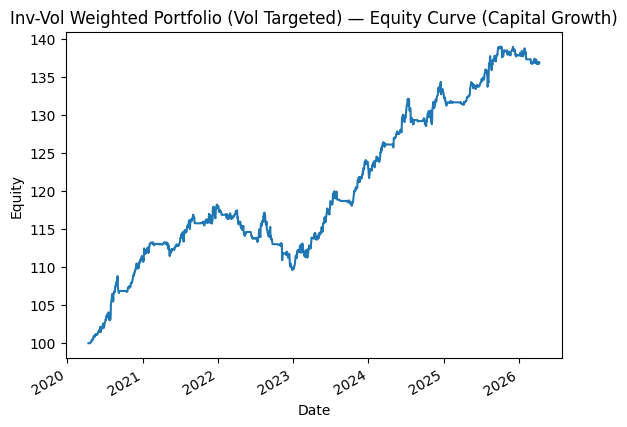

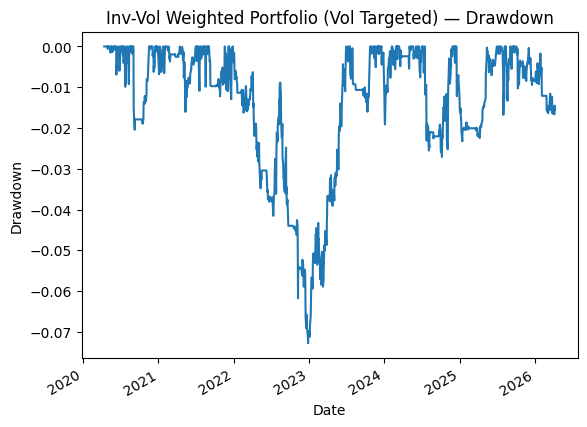

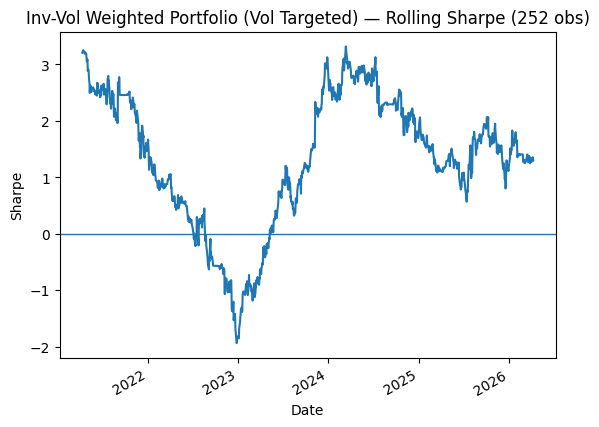

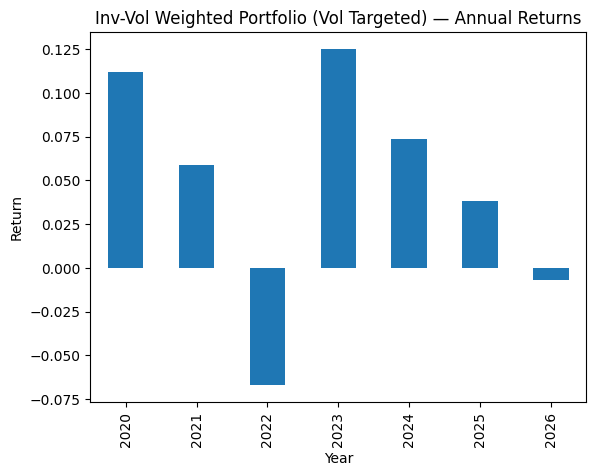

In [38]:
# ---- run plots ----
rs_port, ann_port = plot_portfolio_report(run, title="Inv-Vol Weighted Portfolio (Vol Targeted)", sharpe_window=252, periods_per_year=252)


# 6) Portfolio Implementation- Monthly Rebalancing


Portfolio Construction Logic (Option B: Monthly Signal, Daily Risk Scaling)
This portfolio follows a trend-following framework with monthly execution and daily risk management.
The construction pipeline works as follows:

1. Price Alignment and Returns
All asset price series are aligned on a common time index.
Daily returns are computed using percentage change.

2. Structural Weights
Each asset has a predefined structural allocation weight:
These weights represent the relative allocation budget across assets, not the actual invested capital.

3. Signal Layer
pos_df: Daily diagnostic signal (what the model would do today).
pos_exec: Monthly executed signal.
The executed signal is computed by:
Taking the signal at the last trading day of each month.
Holding it constant until the next rebalance date.
This ensures disciplined trading and reduces turnover.

4. Risk Scaling (Volatility Targeting)
Each asset has a daily volatility scaling factor.
This adjusts exposure dynamically in order to maintain a target volatility per asset.

5. Exposure Calculation
Effective portfolio exposure per asset is defined as:

__Signal * Scale * weight__
 
This represents the percentage of total capital allocated to each asset.
Signal controls direction.
Scale controls risk.
Weight controls relative allocation.

6. Execution Lag (No Look-Ahead Bias)
To avoid look-ahead bias, portfolio returns use lagged exposure:
Today's return is generated by yesterday’s exposure.

7. Equity Curve
Portfolio value evolves through compounding:



In [39]:
close_df = pd.DataFrame({a: close_dict[a].reindex(common_idx) for a in assets})
ret_df   = close_df.pct_change().fillna(0.0)

w = weights.reindex(assets).fillna(0.0).astype(float)
w = w / w.sum()

# Option B: monthly executed signal
reb_dates = pos_df.resample("M").last().index.intersection(common_idx)
pos_exec  = pos_df.loc[reb_dates].reindex(common_idx).ffill().fillna(0.0)
flip_df   = (pos_df != pos_exec).astype(int)

# exposure + execution shift
exposure_df   = pos_exec.mul(scaling_df).mul(w, axis=1)
exposure_exec = exposure_df.shift(1).fillna(0.0)

port_ret = (exposure_exec * ret_df).sum(axis=1)
equity   = (1 + port_ret).cumprod()


# 7) Daily monitoring:

This helper builds a daily monitoring snapshot of the strategy, using the already-computed objects:

pos_df: daily diagnostic signals (what the model would do today)

pos_exec: executed signals (monthly-held positions)

flip_df: indicator of disagreement between daily vs executed signal

scaling_df: daily volatility scaling per asset

exposure_df: effective portfolio exposure per asset (signal × scale × weight)

ret_df: daily returns per asset

w: structural allocation weights


What the function does
Index hygiene: Ensures all input DataFrames have a DatetimeIndex and are sorted (robust to strings/object indices).
Defines the monitoring date: today is the last available date in pos_df.
month_start is the first date available in the current calendar month (used for MTD calculations).

Creates one row per asset
For each asset it collects:

Signal_daily: current diagnostic signal (today)

Signal_exec: current executed/held signal (today)

Flip: 1 if Signal_daily != Signal_exec, else 0

Base_weight: structural weight w_i

Scale_today: today’s volatility scaling factor

Exposure_today: today’s effective exposure (already computed in exposure_df)

MTD_PnL: month-to-date PnL contribution for the asset

MTD PnL is consistent with execution

PnL uses lagged exposure (exposure_df.shift(1)) to avoid look-ahead bias, i.e. today’s return is generated by yesterday’s exposure.

In [40]:
monitoring_today = build_daily_monitoring_v2(
    pos_df=pos_df,
    pos_exec=pos_exec,
    flip_df=flip_df,
    scaling_df=scaling_df,
    exposure_df=exposure_df,
    ret_df=ret_df,
    w=w
)

monitoring_today

,Signal_daily,Signal_exec,Flip,Base_weight,Scale_today,Exposure_today,MTD_PnL
Asset,,,,,,,
SOL,0.0,1.0,1,0.090656,0.108633,0.009848,-0.000128
ETH,1.0,0.0,1,0.094337,0.154173,0.000000,0.000000
Apple,0.0,0.0,0,0.315261,0.314972,0.000000,0.000000
Nasdaq,0.0,0.0,0,0.366932,0.403095,0.000000,0.000000
BTC,1.0,1.0,0,0.132814,0.202014,0.026830,0.001023


# 8) Creating Template for monitoring change in positioning 

In [41]:
NAV_LIVE = 50000

trade_sheet = build_trade_sheet_with_units(
    exposure_df=exposure_df,
    close_df=close_df,
    nav_live=NAV_LIVE,
    min_trade_eur= 200
)

trade_sheet

,Last_Closing_Price,Target_Exposure_%,Delta_€,Units,Action
Asset,,,,,
Apple,258.149994,0.000000,0.000000,0.0,IGNORE
Nasdaq,22555.111328,0.000000,0.000000,0.0,IGNORE
ETH,2168.058838,0.000000,0.000000,0.0,IGNORE
BTC,70738.039062,0.026830,-0.637645,0.0,IGNORE
SOL,81.710548,0.009848,-1.011618,0.0,IGNORE


# 9) Exporting to excel for monitoring purposes:

In [42]:
export_path = "/Users/lollo/Desktop/Indicator tracker file/python export/export_file.xlsx"

In [43]:

df_to_export = [
    monitoring_today,
    trade_sheet,
    summary_df,
    run[['Equity', 'Drawdown']],
    pos_df,
    exposure_df
]

sheets_name = [
    'monitoring',
    'trade_update',
    'summary_strat',
    'ts_ret_dd',
    'signals',
    'exposure'
]


with pd.ExcelWriter(export_path, engine='openpyxl') as writer:
    for df, sheet in zip(df_to_export, sheets_name):
        df.to_excel(writer, sheet_name=sheet)

## TEST

In [44]:
import numpy as np
import pandas as pd

def simulate_portfolio_optionB(
    df_panel: pd.DataFrame,
    assets: list[str],
    best_params: dict,
    weights: pd.Series,
    target_vol_by_asset: dict,
    vol_window_by_asset: dict,
    initial_capital: float = 100.0,
    periods_per_year: int = 252,
    max_scale: float = 1.0,
):
    # --- collect per-asset series ---
    close_dict, ret_dict, score_dict = {}, {}, {}

    for a in assets:
        df_a = get_asset_df(df_panel, a).dropna()
        close = df_a["Close"].astype(float)
        score = df_a["Score"].astype(float)

        close_dict[a] = close
        score_dict[a] = score
        ret_dict[a]   = close.pct_change()

    # --- align on common index ---
    common_idx = None
    for a in assets:
        common_idx = close_dict[a].index if common_idx is None else common_idx.intersection(close_dict[a].index)

    Close = pd.DataFrame({a: close_dict[a].reindex(common_idx) for a in assets})
    Ret   = pd.DataFrame({a: ret_dict[a].reindex(common_idx).fillna(0.0) for a in assets})
    Score = pd.DataFrame({a: score_dict[a].reindex(common_idx) for a in assets})

    # --- daily diagnostic positions from Score ---
    pos_daily = {}
    for a in assets:
        p = best_params[a]
        pos_daily[a] = tf_pos_from_score(
            score=Score[a],
            smooth_method=p["smooth_method"],
            smooth_span=p["smooth_span"],
            smooth_window=p.get("smooth_window", 21),
            mom_lb=p["mom_lb"],
            band=p["band"],
            side=p.get("side", "long"),
        )
    PosDaily = pd.DataFrame(pos_daily).reindex(common_idx).fillna(0.0)

    # --- executed position: freeze direction monthly (month-end) ---
    reb_dates = PosDaily.resample("M").last().index.intersection(common_idx)
    PosExec = PosDaily.loc[reb_dates].reindex(common_idx).ffill().fillna(0.0)

    # --- daily vol scaling from prices (no look-ahead via shift in scaling function) ---
    scale_daily = {}
    for a in assets:
        scale_daily[a] = vol_scaling_from_price(
            price=Close[a],
            target_vol=target_vol_by_asset[a],
            window=vol_window_by_asset[a],
            periods_per_year=periods_per_year,
            max_scale=max_scale,
        )
    Scale = pd.DataFrame(scale_daily).reindex(common_idx).fillna(0.0)

    # --- weights ---
    w = weights.reindex(assets).astype(float).fillna(0.0)
    w = w / w.sum()

    # --- exposure: monthly direction * daily scaling * weights ---
    Exposure = PosExec.mul(Scale).mul(w, axis=1)

    # --- no look-ahead on returns ---
    Exposure_exec = Exposure.shift(1).fillna(0.0)

    port_ret = (Exposure_exec * Ret).sum(axis=1)
    port_ret.name = "PortfolioRet"

    equity = initial_capital * (1.0 + port_ret).cumprod()
    equity.name = "Equity"

    dd = equity / equity.cummax() - 1.0
    dd.name = "Drawdown"

    # --- summary stats ---
    ann_ret = port_ret.mean() * periods_per_year
    ann_vol = port_ret.std(ddof=0) * np.sqrt(periods_per_year)
    sharpe = np.nan if ann_vol == 0 else ann_ret / ann_vol
    total_pnl = equity.iloc[-1] / initial_capital - 1.0
    max_dd = dd.min()

    summary = pd.Series({
        "initial_capital": initial_capital,
        "final_equity": float(equity.iloc[-1]),
        "total_return": float(total_pnl),
        "ann_return": float(ann_ret),
        "ann_vol": float(ann_vol),
        "sharpe": float(sharpe),
        "max_drawdown": float(max_dd),
    })

    run = pd.concat([
        Close.add_prefix("Close_"),
        Score.add_prefix("Score_"),
        PosDaily.add_prefix("PosDaily_"),
        PosExec.add_prefix("PosExec_"),
        Scale.add_prefix("Scale_"),
        Exposure.add_prefix("WgtExp_"),
        Exposure_exec.add_prefix("ExecExp_"),
        Ret.add_prefix("Ret_"),
        port_ret, equity, dd
    ], axis=1)

    # handy extras
    cash_w = 1.0 - Exposure.sum(axis=1)
    cash_w = cash_w.clip(lower=0.0)
    cash_w.name = "CashWeight"

    flip_df = (PosDaily != PosExec).astype(int)

    return {
        "summary": summary,
        "run": run,
        "Close": Close,
        "Ret": Ret,
        "Score": Score,
        "PosDaily": PosDaily,
        "PosExec": PosExec,
        "Scale": Scale,
        "Exposure": Exposure,
        "Exposure_exec": Exposure_exec,
        "CashWeight": cash_w,
        "Flip": flip_df,
        "w": w,
        "reb_dates": reb_dates,
    }

In [45]:
out = simulate_portfolio_optionB(
    df_panel=df_panel,
    assets=assets,
    best_params=best_params,
    weights=weights,
    target_vol_by_asset=target_vol_by_asset,
    vol_window_by_asset=vol_window_by_asset,
    initial_capital=100.0,
    periods_per_year=252,
    max_scale=1.0,
)

summary = out["summary"]
summary

initial_capital    100.000000
final_equity       123.542726
total_return         0.235427
ann_return           0.036164
ann_vol              0.039609
sharpe               0.913016
max_drawdown        -0.079674
dtype: float64

In [46]:
Exposure = out["Exposure"]

turnover_daily = Exposure.diff().abs().sum(axis=1).fillna(0.0)
turnover_monthly = turnover_daily.groupby(turnover_daily.index.to_period("M")).sum()

eps = 1e-4
trade_days_share = (turnover_daily > eps).mean()

print("Avg daily turnover:", float(turnover_daily.mean()))
print("Avg monthly turnover:", float(turnover_monthly.mean()))
print("Share of days with trades:", float(trade_days_share))

turnover_monthly.tail()

Avg daily turnover: 0.006467665380703598
Avg monthly turnover: 0.13342882278547422
Share of days with trades: 0.6520584329349269


Date
2025-12    0.204057
2026-01    0.005483
2026-02    0.008889
2026-03    0.023552
2026-04    0.000904
Freq: M, dtype: float64

In [47]:
gross = Exposure.abs().sum(axis=1)
net   = Exposure.sum(axis=1)

top2 = Exposure.abs().apply(
    lambda s: s.sort_values(ascending=False).head(2).sum(), axis=1
)

print("Gross exposure mean / max:", float(gross.mean()), float(gross.max()))
print("Top-2 exposure mean / max:", float(top2.mean()), float(top2.max()))

Gross exposure mean / max: 0.14237994318918823 0.4344222093393504
Top-2 exposure mean / max: 0.13164354013830745 0.4344222093393504


In [48]:
def quick_robustness_test_optionB(
    df_panel, assets, best_params, weights,
    target_vol_by_asset, vol_window_by_asset,
    bump_mom=(0.8, 1.0, 1.2),
    bump_band=(0.8, 1.0, 1.2),
    bump_span=(0.8, 1.0, 1.2),
    initial_capital=100.0,
    periods_per_year=252,
    max_scale=1.0
):
    rows = []
    for km in bump_mom:
        for kb in bump_band:
            for ks in bump_span:
                # bumped params
                bp = {}
                for a in assets:
                    p = best_params[a].copy()
                    p["mom_lb"] = max(2, int(round(p["mom_lb"] * km)))
                    p["band"]   = float(p["band"] * kb)
                    p["smooth_span"] = max(2, int(round(p["smooth_span"] * ks)))
                    bp[a] = p

                out_b = simulate_portfolio_optionB(
                    df_panel=df_panel,
                    assets=assets,
                    best_params=bp,
                    weights=weights,
                    target_vol_by_asset=target_vol_by_asset,
                    vol_window_by_asset=vol_window_by_asset,
                    initial_capital=initial_capital,
                    periods_per_year=periods_per_year,
                    max_scale=max_scale,
                )
                s = out_b["summary"]
                rows.append({
                    "mom_mult": km, "band_mult": kb, "span_mult": ks,
                    "ann_return": float(s["ann_return"]),
                    "ann_vol": float(s["ann_vol"]),
                    "sharpe": float(s["sharpe"]),
                    "max_dd": float(s["max_drawdown"]),
                    "total_return": float(s["total_return"]),
                })
    return pd.DataFrame(rows).sort_values("sharpe", ascending=False)

rob = quick_robustness_test_optionB(
    df_panel=df_panel,
    assets=assets,
    best_params=best_params,
    weights=weights,
    target_vol_by_asset=target_vol_by_asset,
    vol_window_by_asset=vol_window_by_asset,
    initial_capital=100.0,
    max_scale=1.0
)

rob.head(10)

,mom_mult,band_mult,span_mult,ann_return,ann_vol,sharpe,max_dd,total_return
2,0.8,0.8,1.2,0.038352,0.039146,0.979716,-0.080006,0.251825
11,1.0,0.8,1.2,0.037419,0.039706,0.942398,-0.079674,0.244698
10,1.0,0.8,1.0,0.037295,0.039768,0.937829,-0.079674,0.243762
9,1.0,0.8,0.8,0.035904,0.038716,0.927378,-0.080006,0.233772
5,0.8,1.0,1.2,0.035346,0.038419,0.920019,-0.080006,0.229747
14,1.0,1.0,1.2,0.035891,0.039045,0.919224,-0.079674,0.233580
13,1.0,1.0,1.0,0.036164,0.039609,0.913016,-0.079674,0.235427
17,1.0,1.2,1.2,0.035254,0.038812,0.908308,-0.079674,0.228958
16,1.0,1.2,1.0,0.034511,0.038283,0.901473,-0.079674,0.223669
12,1.0,1.0,0.8,0.034400,0.038354,0.896918,-0.080006,0.222838
